# Day 37 - Predicting Future Revenue with Time Series Models
### 60 Days Data Science | Phase: Business Forecasting

**Date:** 19 June 2026  
**Name:** Rajesh Yadav

---


## Step 1 - Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from statsmodels.tsa.stattools import adfuller
from statsmodels.tsa.statespace.sarimax import SARIMAX
from sklearn.metrics import mean_absolute_error, mean_squared_error

# Make plots look professional and clean
sns.set_theme(style="whitegrid")
plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["font.size"] = 10

print("numpy version:", np.__version__)
print("pandas version:", pd.__version__)


numpy version: 2.2.1
pandas version: 2.2.3


## Step 2 - Simulating Revenue Data

In [2]:
np.random.seed(42)
dates = pd.date_range(start='2023-01-01', end='2025-12-31', freq='D')
n_days = len(dates)

# 1. Base revenue + Trend
base_rev = 1500
trend = 2.2 * np.arange(n_days)

# 2. Weekly Seasonality (0=Monday, 6=Sunday)
# B2B SaaS: high activity mid-week, drops significantly on weekends
weekly_pattern = {0: 120, 1: 250, 2: 300, 3: 280, 4: 150, 5: -450, 6: -550}
weekly_seasonality = np.array([weekly_pattern[d.dayofweek] for d in dates])

# 3. Yearly Seasonality (Q4 holiday spikes + seasonal wave)
yearly_wave = 300 * np.sin(2 * np.pi * dates.dayofyear / 365.25)
holiday_boost = np.zeros(n_days)
for i, date in enumerate(dates):
    if date.month == 11 and date.day >= 20: # Black Friday / Cyber Monday promo boost
        holiday_boost[i] = 800 + np.random.normal(0, 100)
    elif date.month == 12 and date.day <= 25: # December holiday rush
        holiday_boost[i] = 1200 + np.random.normal(0, 150)

# 4. Outliers/Shocks (Outages & Promo Spikes)
shocks = np.zeros(n_days)
# Server outages (sharp revenue drop)
outage_days = np.random.choice(n_days, size=5, replace=False)
shocks[outage_days] = -1200
# Successful promo campaigns (sharp revenue spike)
promo_days = np.random.choice(n_days, size=5, replace=False)
shocks[promo_days] = 2000

# 5. Gaussian Noise
noise = np.random.normal(0, 180, n_days)

# Combine components into daily revenue
revenue = base_rev + trend + weekly_seasonality + yearly_wave + holiday_boost + shocks + noise
# Clip negative revenue values to make them realistic (min $200 daily revenue)
revenue = np.clip(revenue, 200, None)

df = pd.DataFrame({'Date': dates, 'Revenue': revenue})
df.set_index('Date', inplace=True)

print(f"Dataset generated. Shape: {df.shape}")
print(df.head())


Dataset generated. Shape: (1096, 1)
                Revenue
Date                   
2023-01-01  1161.078298
2023-01-02  1269.711520
2023-01-03  1668.607259
2023-01-04  1718.941560
2023-01-05  2109.679790


## Step 3 - Exploratory Data Analysis (EDA)

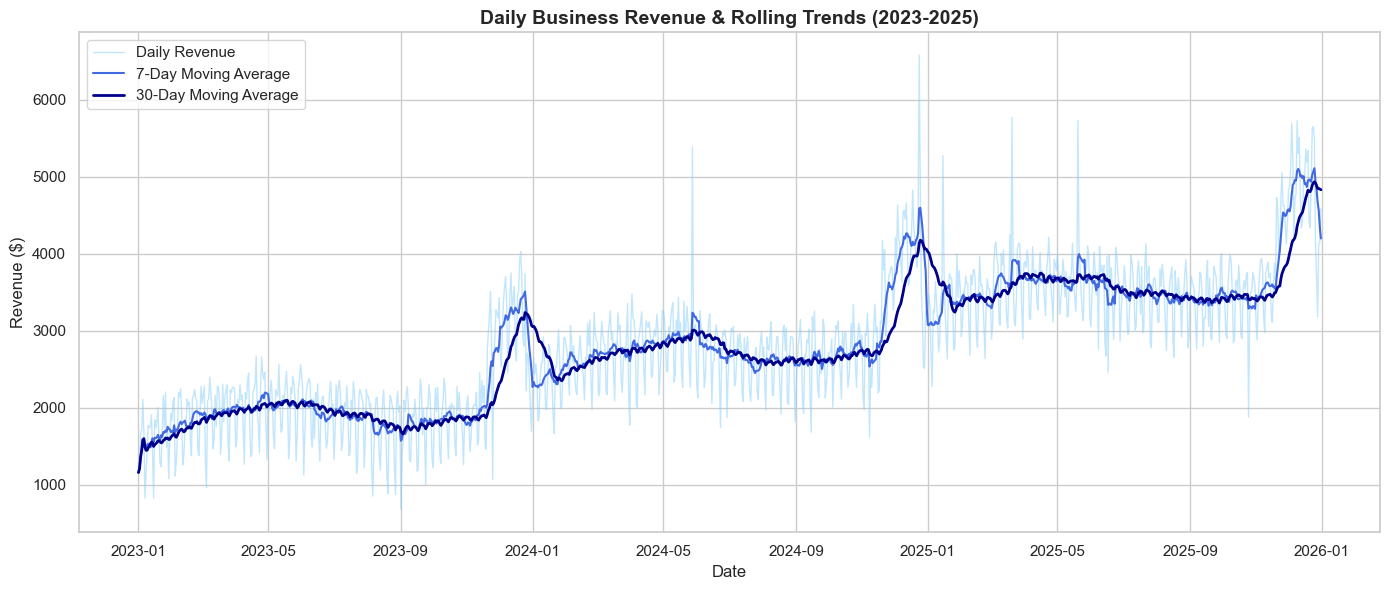

In [3]:
df['7d_MA'] = df['Revenue'].rolling(window=7, min_periods=1).mean()
df['30d_MA'] = df['Revenue'].rolling(window=30, min_periods=1).mean()

plt.figure(figsize=(14, 6))
plt.plot(df.index, df['Revenue'], label='Daily Revenue', color='lightskyblue', alpha=0.5, linewidth=1)
plt.plot(df.index, df['7d_MA'], label='7-Day Moving Average', color='royalblue', linewidth=1.5)
plt.plot(df.index, df['30d_MA'], label='30-Day Moving Average', color='darkblue', linewidth=2)
plt.title('Daily Business Revenue & Rolling Trends (2023-2025)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


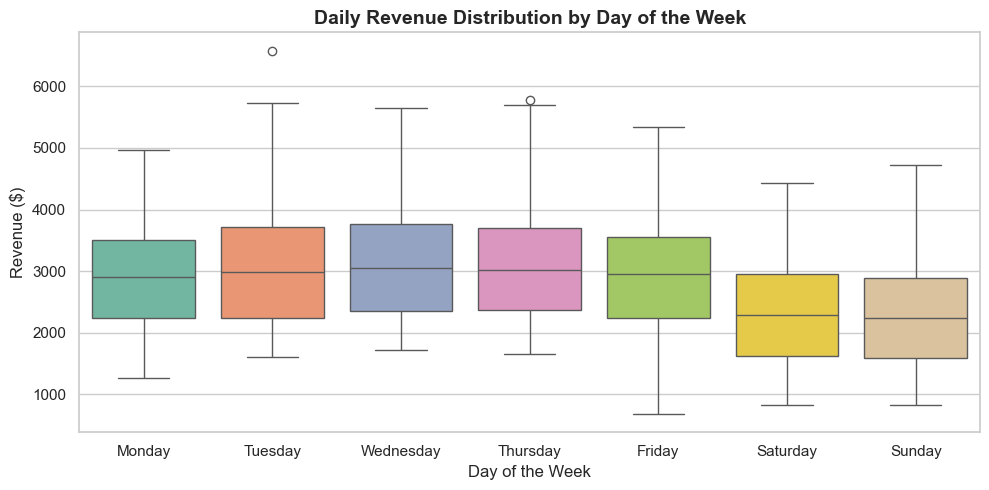

In [4]:
# Check day of week pattern
df['DayOfWeek'] = df.index.day_name()
day_order = ['Monday', 'Tuesday', 'Wednesday', 'Thursday', 'Friday', 'Saturday', 'Sunday']

plt.figure(figsize=(10, 5))
sns.boxplot(x='DayOfWeek', y='Revenue', data=df, order=day_order, palette='Set2')
plt.title('Daily Revenue Distribution by Day of the Week', fontsize=14, fontweight='bold')
plt.xlabel('Day of the Week', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.tight_layout()
plt.show()


## Step 4 - Stationarity Check (ADF Test)

In [5]:
def run_adf_test(series, name):
    result = adfuller(series.dropna())
    print(f"ADF Test Results for: {name}")
    print(f"ADF Statistic: {result[0]:.4f}")
    print(f"p-value: {result[1]:.4e}")
    print(f"Lags Used: {result[2]}")
    print(f"Observations: {result[3]}")
    print("Critical Values:")
    for key, value in result[4].items():
        print(f"   {key}: {value:.4f}")
    if result[1] <= 0.05:
        print("Conclusion: Reject H0. The series is STATIONARY.\n")
    else:
        print("Conclusion: Fail to reject H0. The series is NON-STATIONARY.\n")

run_adf_test(df['Revenue'], 'Raw Revenue')


ADF Test Results for: Raw Revenue
ADF Statistic: -1.9139
p-value: 3.2554e-01
Lags Used: 22
Observations: 1073
Critical Values:
   1%: -3.4365
   5%: -2.8642
   10%: -2.5682
Conclusion: Fail to reject H0. The series is NON-STATIONARY.



## Step 5 - Stationarity Check on Differenced Series

In [6]:
df['Revenue_Diff'] = df['Revenue'].diff()
run_adf_test(df['Revenue_Diff'], '1st Differenced Revenue')


ADF Test Results for: 1st Differenced Revenue
ADF Statistic: -6.9606
p-value: 9.1868e-10
Lags Used: 21
Observations: 1073
Critical Values:
   1%: -3.4365
   5%: -2.8642
   10%: -2.5682
Conclusion: Reject H0. The series is STATIONARY.



## Step 6 - Train-Test Split & Baseline Model

In [7]:
# Split into Train/Test
train = df.iloc[:-31].copy()
test = df.iloc[-31:].copy()

print(f"Train size: {len(train)} days (up to {train.index.max().date()})")
print(f"Test size:  {len(test)} days (from {test.index.min().date()} to {test.index.max().date()})")

# Seasonal Naive baseline
test['Baseline_Forecast'] = df['Revenue'].shift(7).loc[test.index]
print(test[['Revenue', 'Baseline_Forecast']].head())


Train size: 1065 days (up to 2025-11-30)
Test size:  31 days (from 2025-12-01 to 2025-12-31)
                Revenue  Baseline_Forecast
Date                                      
2025-12-01  4823.079265        4721.165488
2025-12-02  4869.792429        5054.670890
2025-12-03  5115.605604        4623.073434
2025-12-04  5699.621693        4627.160001
2025-12-05  5258.987783        4388.579294


## Step 7 - SARIMAX Model

In [8]:
# Fit SARIMAX on train data
model = SARIMAX(train['Revenue'],
                order=(1, 1, 1),
                seasonal_order=(1, 1, 1, 7),
                enforce_stationarity=False,
                enforce_invertibility=False)
model_fit = model.fit(disp=False)

print(model_fit.summary())


C:\Users\RAJESH YADAV\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\RAJESH YADAV\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


                                     SARIMAX Results                                     
Dep. Variable:                           Revenue   No. Observations:                 1065
Model:             SARIMAX(1, 1, 1)x(1, 1, 1, 7)   Log Likelihood               -7415.895
Date:                           Fri, 19 Jun 2026   AIC                          14841.791
Time:                                   06:49:47   BIC                          14866.564
Sample:                               01-01-2023   HQIC                         14851.185
                                    - 11-30-2025                                         
Covariance Type:                             opg                                         
                 coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------
ar.L1          0.0003      0.023      0.011      0.991      -0.045       0.046
ma.L1         -0.7310      0.018    -41.031

## Step 8 - Predictions vs Test Set

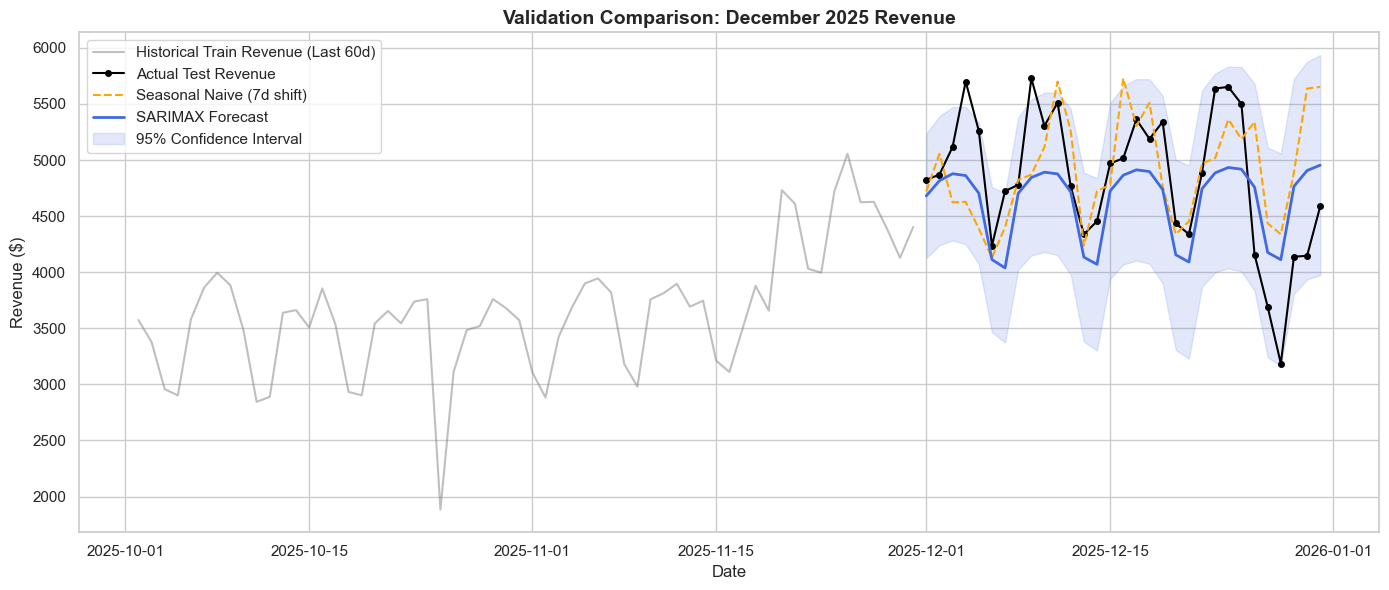

In [9]:
# Get forecast and confidence intervals
forecast_res = model_fit.get_forecast(steps=31)
test['SARIMAX_Forecast'] = forecast_res.predicted_mean
ci = forecast_res.conf_int()

plt.figure(figsize=(14, 6))
plt.plot(train.index[-60:], train['Revenue'].iloc[-60:], label='Historical Train Revenue (Last 60d)', color='gray', alpha=0.5)
plt.plot(test.index, test['Revenue'], label='Actual Test Revenue', color='black', marker='o', markersize=4)
plt.plot(test.index, test['Baseline_Forecast'], label='Seasonal Naive (7d shift)', color='orange', linestyle='--')
plt.plot(test.index, test['SARIMAX_Forecast'], label='SARIMAX Forecast', color='royalblue', linewidth=2)
plt.fill_between(test.index, ci.iloc[:, 0], ci.iloc[:, 1], color='royalblue', alpha=0.15, label='95% Confidence Interval')

plt.title('Validation Comparison: December 2025 Revenue', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


## Step 9 - Model Evaluation Metrics

In [10]:
def calculate_metrics(actual, predicted, model_name):
    mae = mean_absolute_error(actual, predicted)
    rmse = np.sqrt(mean_squared_error(actual, predicted))
    mape = np.mean(np.abs((actual - predicted) / actual)) * 100
    return pd.Series({'MAE': mae, 'RMSE': rmse, 'MAPE (%)': mape}, name=model_name)

metrics_df = pd.DataFrame([
    calculate_metrics(test['Revenue'], test['Baseline_Forecast'], 'Seasonal Naive Baseline'),
    calculate_metrics(test['Revenue'], test['SARIMAX_Forecast'], 'SARIMAX Model')
])

print("Validation Set Model Comparison:")
print(metrics_df.round(2))


Validation Set Model Comparison:
                            MAE    RMSE  MAPE (%)
Seasonal Naive Baseline  485.82  628.14     10.60
SARIMAX Model            435.83  508.03      9.19


## Step 10 - Future Forecasting (January 2026)

C:\Users\RAJESH YADAV\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)
C:\Users\RAJESH YADAV\AppData\Roaming\Python\Python310\site-packages\statsmodels\tsa\base\tsa_model.py:473: ValueWarning: No frequency information was provided, so inferred frequency D will be used.
  self._init_dates(dates, freq)


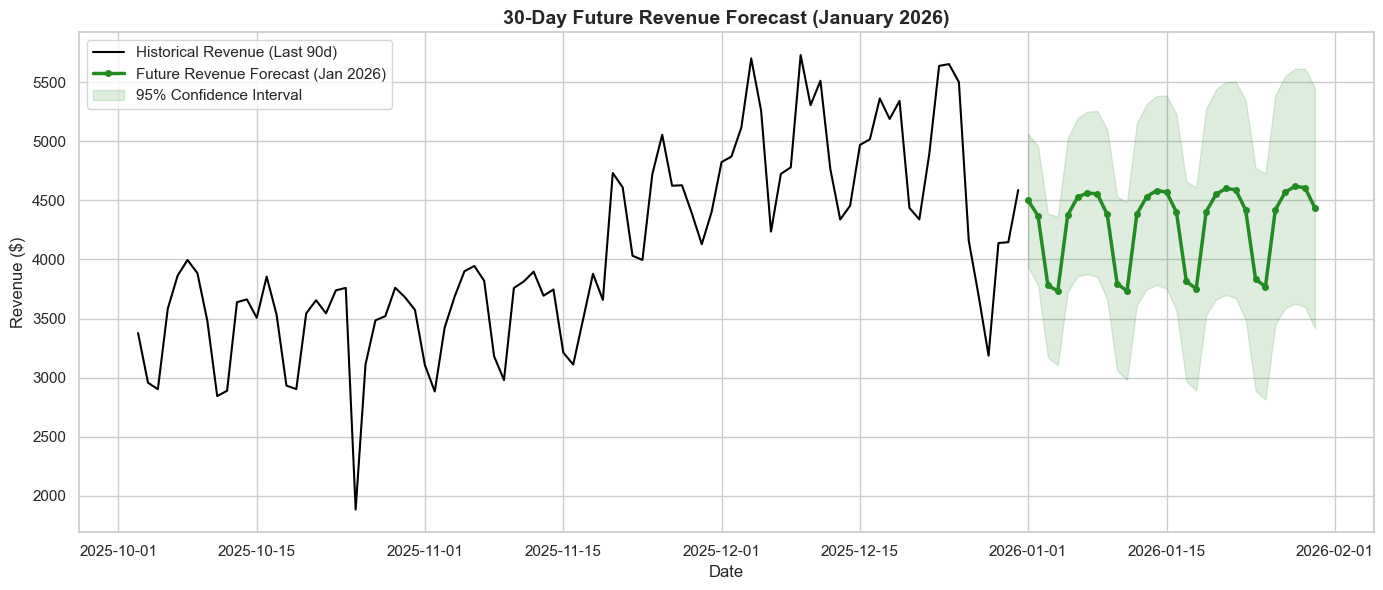

In [11]:
# Retrain on full history
final_model = SARIMAX(df['Revenue'],
                      order=(1, 1, 1),
                      seasonal_order=(1, 1, 1, 7),
                      enforce_stationarity=False,
                      enforce_invertibility=False)
final_model_fit = final_model.fit(disp=False)

# Forecast 30 days ahead
forecast_steps = 30
future_forecast = final_model_fit.get_forecast(steps=forecast_steps)
future_dates = pd.date_range(start='2026-01-01', periods=forecast_steps, freq='D')

forecast_df = pd.DataFrame({
    'Forecast': future_forecast.predicted_mean.values,
}, index=future_dates)

future_ci = future_forecast.conf_int()
forecast_df['Lower_CI'] = future_ci.iloc[:, 0].values
forecast_df['Upper_CI'] = future_ci.iloc[:, 1].values

# Plot the historical series (last 90 days) and the 30-day forecast
plt.figure(figsize=(14, 6))
plt.plot(df.index[-90:], df['Revenue'].iloc[-90:], label='Historical Revenue (Last 90d)', color='black')
plt.plot(forecast_df.index, forecast_df['Forecast'], label='Future Revenue Forecast (Jan 2026)', color='forestgreen', linewidth=2.5, marker='o', markersize=4)
plt.fill_between(forecast_df.index, forecast_df['Lower_CI'], forecast_df['Upper_CI'], color='forestgreen', alpha=0.15, label='95% Confidence Interval')

plt.title('30-Day Future Revenue Forecast (January 2026)', fontsize=14, fontweight='bold')
plt.xlabel('Date', fontsize=12)
plt.ylabel('Revenue ($)', fontsize=12)
plt.legend(loc='upper left')
plt.tight_layout()
plt.show()


In [12]:
# Calculate total forecasted revenue and print insights
print("First 7 Days of January 2026 Forecast:")
print(forecast_df.head(7).round(2))

total_forecast = forecast_df['Forecast'].sum()
lower_total = forecast_df['Lower_CI'].sum()
upper_total = forecast_df['Upper_CI'].sum()

print("-" * 50)
print(f"Total Forecasted Revenue for January 2026: ${total_forecast:,.2f}")
print(f"95% Confidence Range: ${lower_total:,.2f} to ${upper_total:,.2f}")
print("-" * 50)


First 7 Days of January 2026 Forecast:
            Forecast  Lower_CI  Upper_CI
2026-01-01   4499.62   3936.35   5062.90
2026-01-02   4369.11   3782.71   4955.51
2026-01-03   3779.77   3171.83   4387.72
2026-01-04   3732.71   3103.96   4361.47
2026-01-05   4373.23   3724.33   5022.12
2026-01-06   4526.09   3857.66   5194.52
2026-01-07   4562.74   3875.34   5250.15
--------------------------------------------------
Total Forecasted Revenue for January 2026: $129,147.52
95% Confidence Range: $104,768.97 to $153,526.06
--------------------------------------------------


## Step 11 - Key Takeaways
- SARIMAX(1, 1, 1)x(1, 1, 1)7 captures trend and weekly cycles.
- Under-forecasting results in staffing/capacity limits, while over-forecasting drains capital runway.
